# Test 1: Torus Baseline Comparison

This keeps the baseline comparison compact, but restores distribution-style torus diagnostics instead of only reporting new summary plots.

In [1]:
from dataclasses import replace
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir, save_figure, finish_layout, polish_axes

setup_plot_style(scale=1.5)
np.random.seed(42)

from systems import TorusConfig, sample_torus, torus_sde_step, init_torus_particles, cartesian_to_angles, angles_to_cartesian, project_to_torus
from kswgd import fit_spectral_model, run_kswgd
from baseline import kde_score, mmd_rbf, sliced_wasserstein, torus_phi_tv, run_matrix_svgd, run_svgd, run_torus_flow_matching, run_torus_ula
from experiment_plots import plot_torus_triptych, plot_torus_angular, plot_torus_overlap_matrix

# Match the successful KSWGD torus setup used in test_1_torus.ipynb.
R = 2.0
r = 0.8
DT_SNAPSHOT = 0.05
H_KSWGD = 0.005
THETA_INIT_CENTER = 0.0
PHI_INIT_CENTER = np.pi / 2
THETA_SPREAD = 0.3
PHI_SPREAD = 0.3
N_TARGET = 800
N_PARTICLES_KSWGD = 2000
N_ITER_KSWGD = 5000
MAX_MODES = 80
MAX_STEP_NORM = None

# Keep the non-KSWGD baselines compact; their particle updates are much more expensive.
N_PARTICLES_BASELINE = 500
N_ITER_BASELINE = 500
N_ITER_ULA = 300

cfg = TorusConfig(
    R=R, r=r, n_target=N_TARGET, n_particles=N_PARTICLES_KSWGD, n_iter=N_ITER_KSWGD,
    step_size=H_KSWGD, dt_edmd=DT_SNAPSHOT, theta_init_center=THETA_INIT_CENTER,
    phi_init_center=PHI_INIT_CENTER, theta_spread=THETA_SPREAD,
    phi_spread=PHI_SPREAD, seed=42,
)
USE_GPU = True
RUN_FLOW_BASELINES = True
FLOW_EPOCHS = 20
ensure_dir('figures/torus')
print(cfg)


TorusConfig(R=2.0, r=0.8, n_target=800, n_particles=2000, n_iter=5000, step_size=0.005, dt_edmd=0.05, theta_init_center=0.0, phi_init_center=1.5707963267948966, theta_spread=0.3, phi_spread=0.3, seed=42)


In [2]:
X_tar, theta_tar, phi_tar = sample_torus(cfg)
X_next, _, _ = torus_sde_step(theta_tar, phi_tar, cfg)
X_init = init_torus_particles(cfg)
theta_init, phi_init = cartesian_to_angles(X_init, cfg.R, cfg.r)
model = fit_spectral_model(X_tar, X_next, max_modes=MAX_MODES, method='KSWGD')
kswgd = run_kswgd(
    model, X_init, n_iter=N_ITER_KSWGD, step_size=H_KSWGD,
    snapshot_steps=[0, N_ITER_KSWGD], use_gpu=USE_GPU,
    torus=(cfg.R, cfg.r), max_step_norm=MAX_STEP_NORM, progress=False,
)
X_init_baseline = X_init[:N_PARTICLES_BASELINE].copy()
theta_init_baseline, phi_init_baseline = cartesian_to_angles(X_init_baseline, cfg.R, cfg.r)
project = lambda points: project_to_torus(points, cfg.R, cfg.r)
score_fn = lambda X: kde_score(X, X_tar, bandwidth=model.epsilon)
ula = run_torus_ula(theta_init_baseline, phi_init_baseline, R=cfg.R, r=cfg.r, n_iter=N_ITER_ULA, dt=0.05, seed=cfg.seed + 1, include_surface_drift=False, to_cartesian=angles_to_cartesian)
svgd = run_svgd(X_init_baseline, score_fn=score_fn, n_iter=N_ITER_BASELINE, step_size=0.01, project_fn=project, max_step_norm=0.04)
msvgd = run_matrix_svgd(X_init_baseline, score_fn=score_fn, n_iter=N_ITER_BASELINE, step_size=0.012, project_fn=project, max_step_norm=0.04)
methods = {'KSWGD': kswgd.final, 'ULA': ula.final, 'SVGD': svgd.final, 'Matrix SVGD': msvgd.final}
if RUN_FLOW_BASELINES:
    rfm = run_torus_flow_matching(theta_init_baseline, phi_init_baseline, theta_tar, phi_tar, R=cfg.R, r=cfg.r, n_epochs=FLOW_EPOCHS, seed=cfg.seed + 3, generalized=False)
    gfm = run_torus_flow_matching(theta_init_baseline, phi_init_baseline, theta_tar, phi_tar, R=cfg.R, r=cfg.r, n_epochs=FLOW_EPOCHS, seed=cfg.seed + 4, generalized=True)
    methods['RFM'] = rfm.final
    methods['GFM'] = gfm.final
for name, X in methods.items():
    print(f"{name:12s} MMD={mmd_rbf(X_tar, X):.4f} SW={sliced_wasserstein(X_tar, X, seed=cfg.seed):.4f} phi-TV={torus_phi_tv(X, cfg.R, cfg.r):.4f}")


KSWGD        MMD=0.0337 SW=0.0639 phi-TV=0.1208
ULA          MMD=0.0902 SW=0.1489 phi-TV=0.1717
SVGD         MMD=0.6894 SW=1.4961 phi-TV=0.6665
Matrix SVGD  MMD=0.6533 SW=1.4561 phi-TV=0.6420
RFM          MMD=0.2852 SW=0.4553 phi-TV=0.5257


GFM          MMD=0.2861 SW=0.4268 phi-TV=0.5719


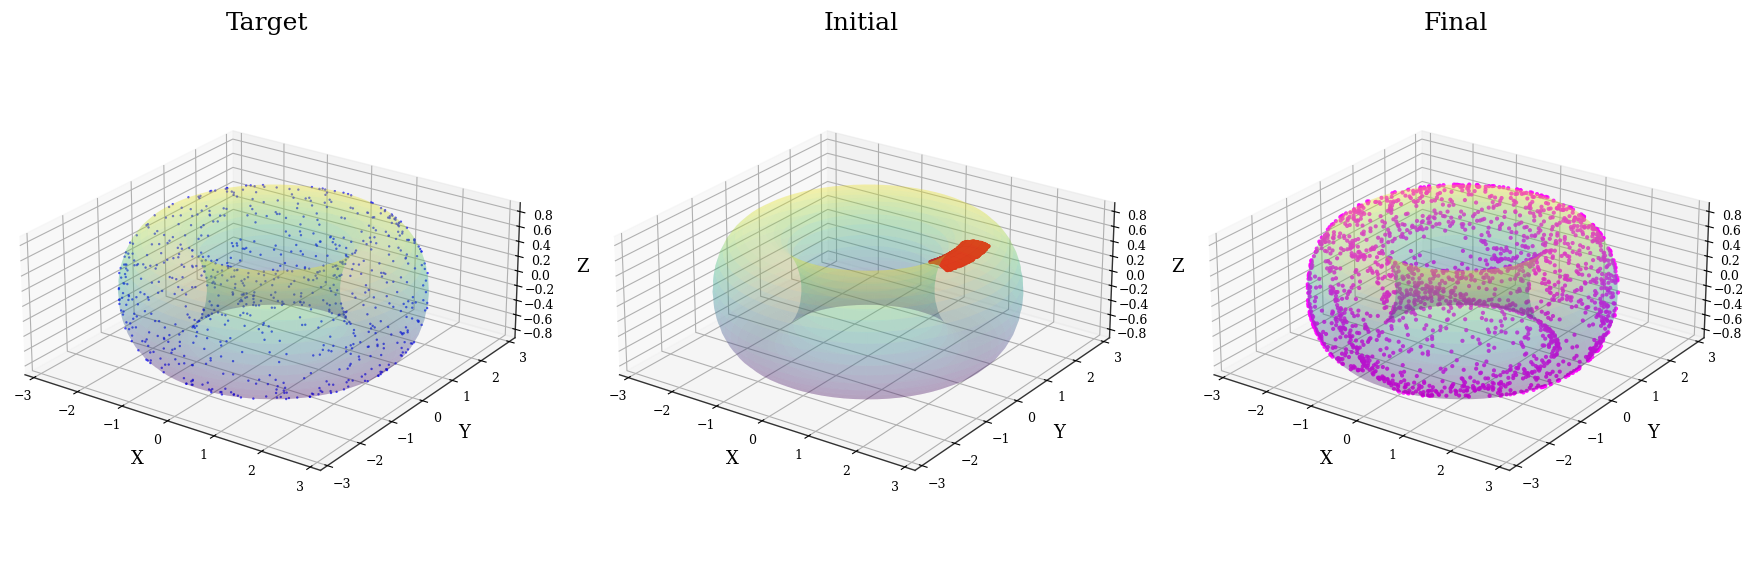

Caption: Baseline notebook reference panel: torus target, shared localized initialization, and KSWGD final particles.
Saved: figures/torus/baseline_kswgd_reference_torus.png and figures/torus/baseline_kswgd_reference_torus.pdf


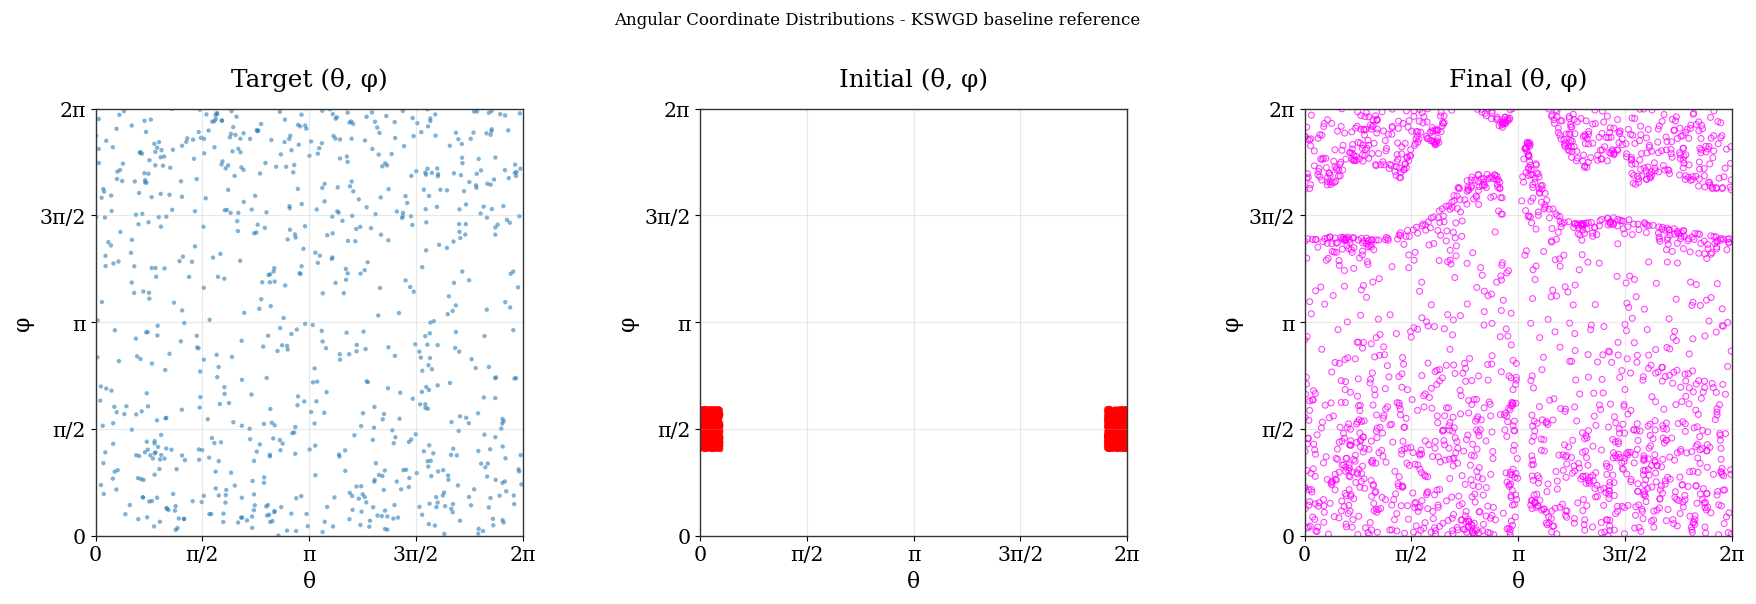

Caption: Angular-coordinate target, initialization, and KSWGD final distribution used as the reference in the torus baseline comparison.
Saved: figures/torus/baseline_kswgd_reference_angles.png and figures/torus/baseline_kswgd_reference_angles.pdf


In [3]:
plot_torus_triptych(
    X_tar, X_init, methods['KSWGD'], R=cfg.R, r=cfg.r, method='KSWGD baseline reference',
    stem='figures/torus/baseline_kswgd_reference_torus',
    caption='Baseline notebook reference panel: torus target, shared localized initialization, and KSWGD final particles.',
)
plot_torus_angular(
    theta_tar, phi_tar, theta_init, phi_init, *cartesian_to_angles(methods['KSWGD'], cfg.R, cfg.r),
    method='KSWGD baseline reference', stem='figures/torus/baseline_kswgd_reference_angles',
    caption='Angular-coordinate target, initialization, and KSWGD final distribution used as the reference in the torus baseline comparison.',
)


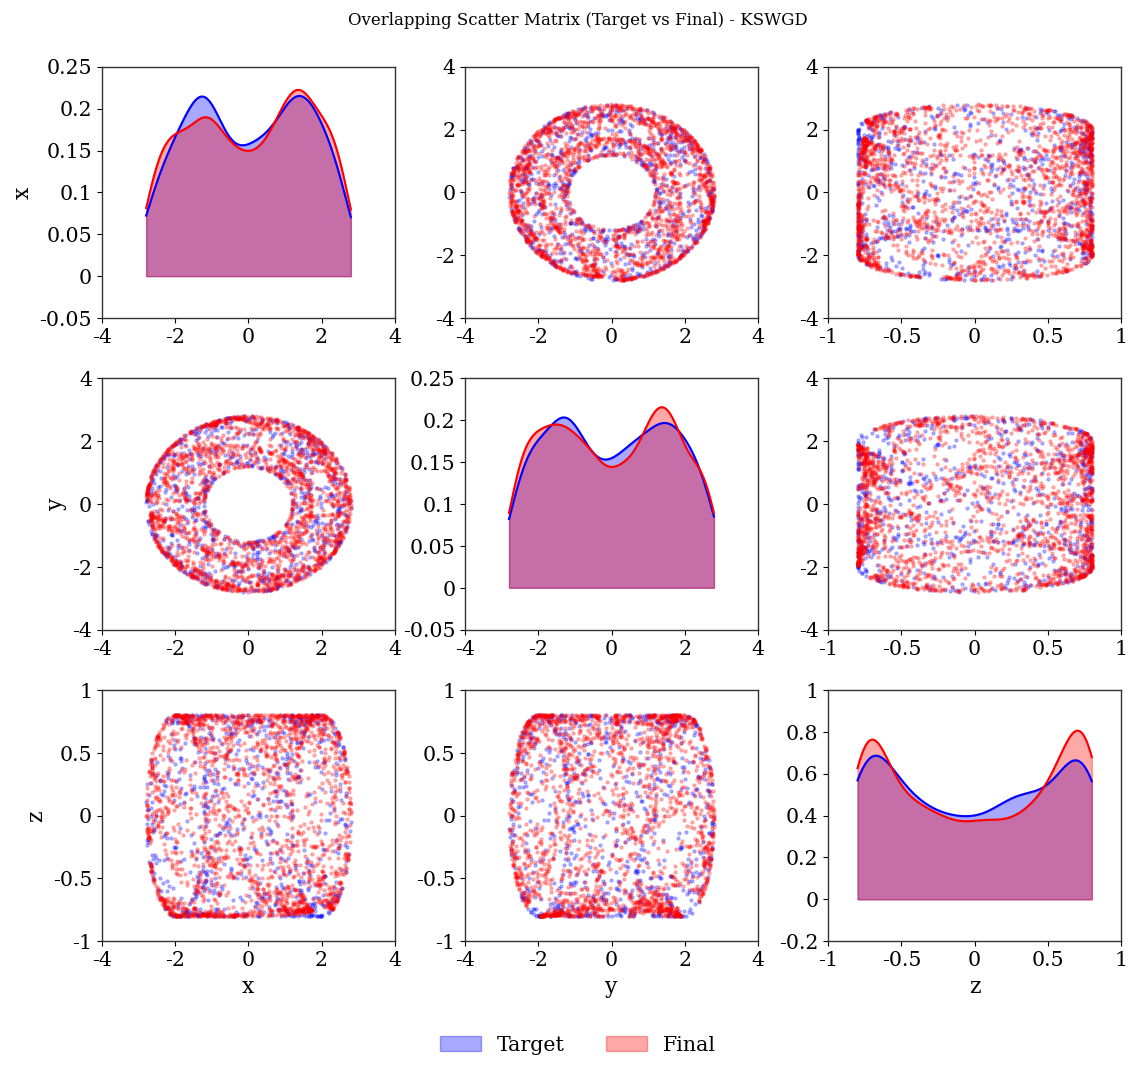

Caption: Overlapping scatter matrix comparing the torus target with final KSWGD particles.
Saved: figures/torus/baseline_kswgd_overlap_matrix.png and figures/torus/baseline_kswgd_overlap_matrix.pdf


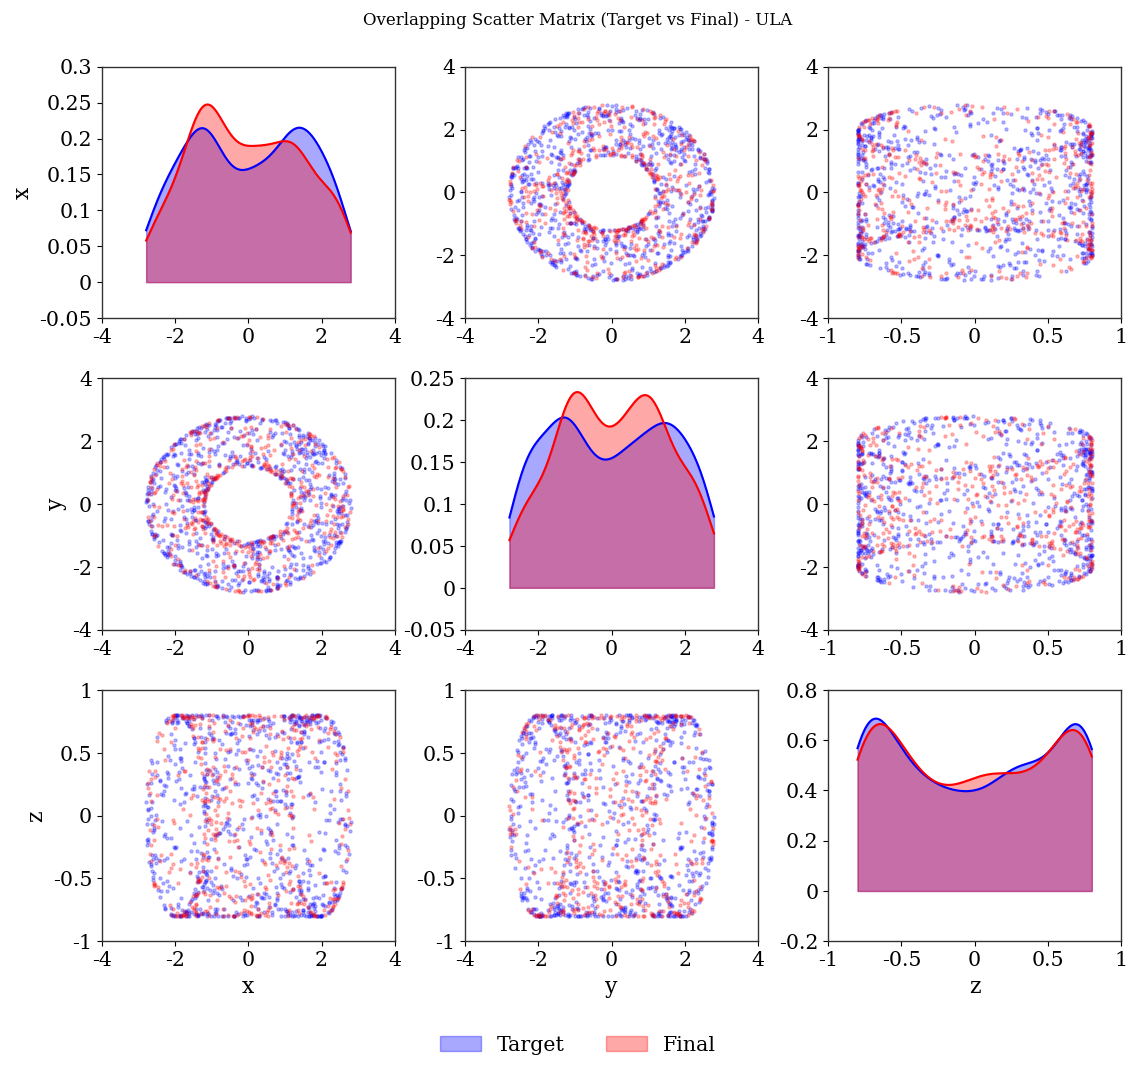

Caption: Overlapping scatter matrix comparing the torus target with final ULA particles.
Saved: figures/torus/baseline_ula_overlap_matrix.png and figures/torus/baseline_ula_overlap_matrix.pdf


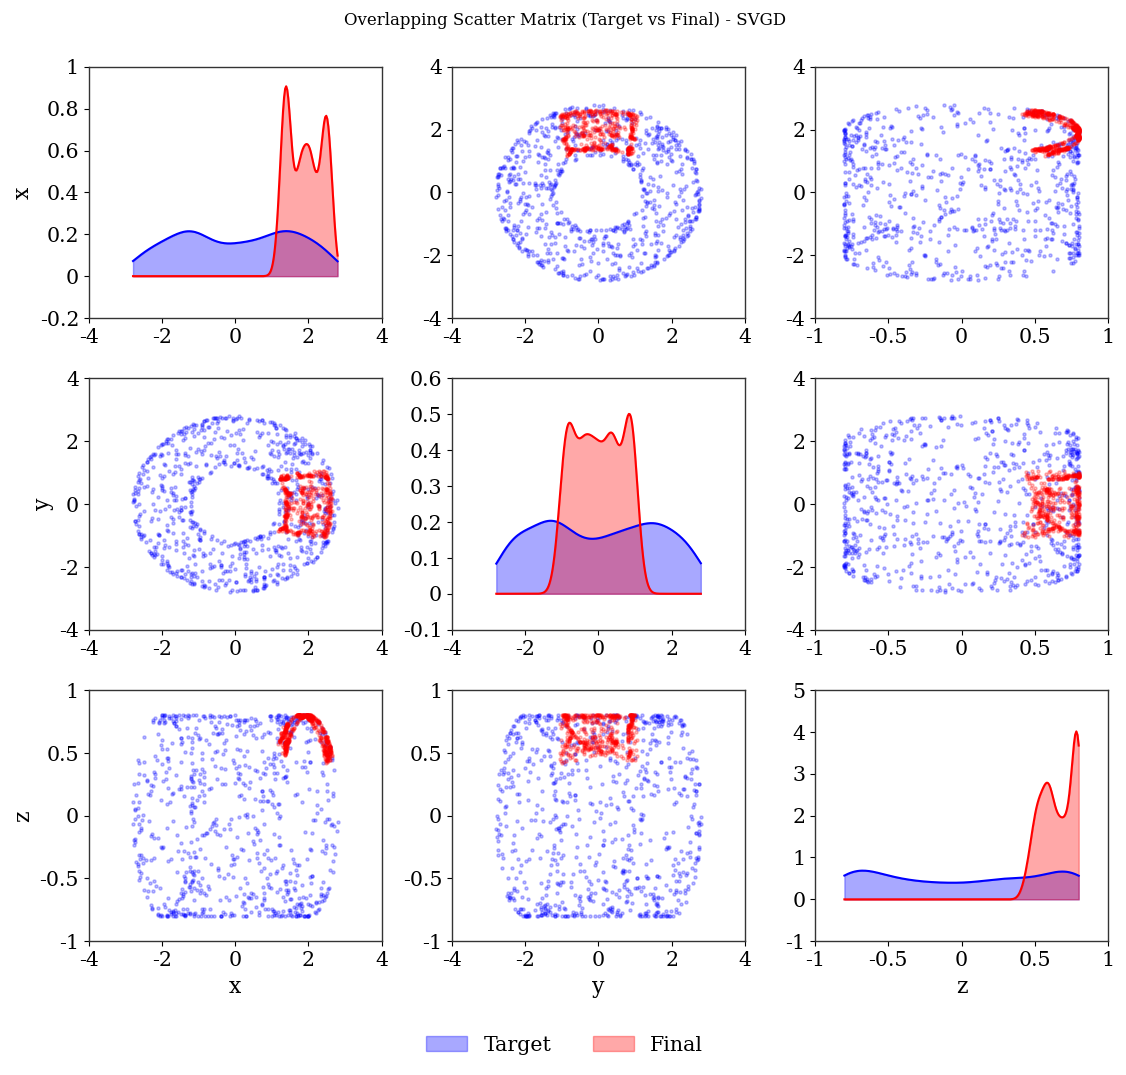

Caption: Overlapping scatter matrix comparing the torus target with final SVGD particles.
Saved: figures/torus/baseline_svgd_overlap_matrix.png and figures/torus/baseline_svgd_overlap_matrix.pdf


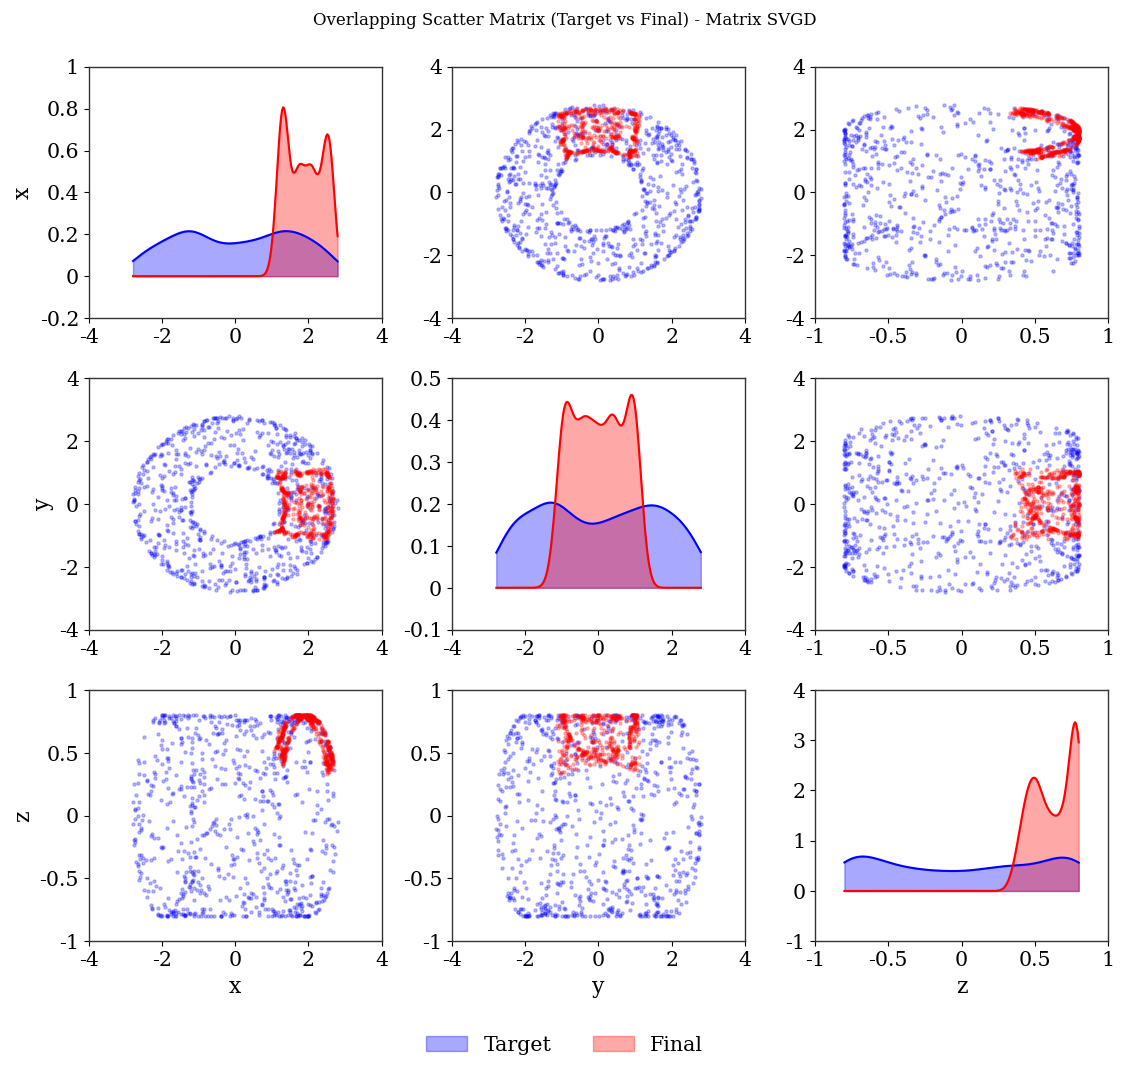

Caption: Overlapping scatter matrix comparing the torus target with final Matrix SVGD particles.
Saved: figures/torus/baseline_matrix_svgd_overlap_matrix.png and figures/torus/baseline_matrix_svgd_overlap_matrix.pdf


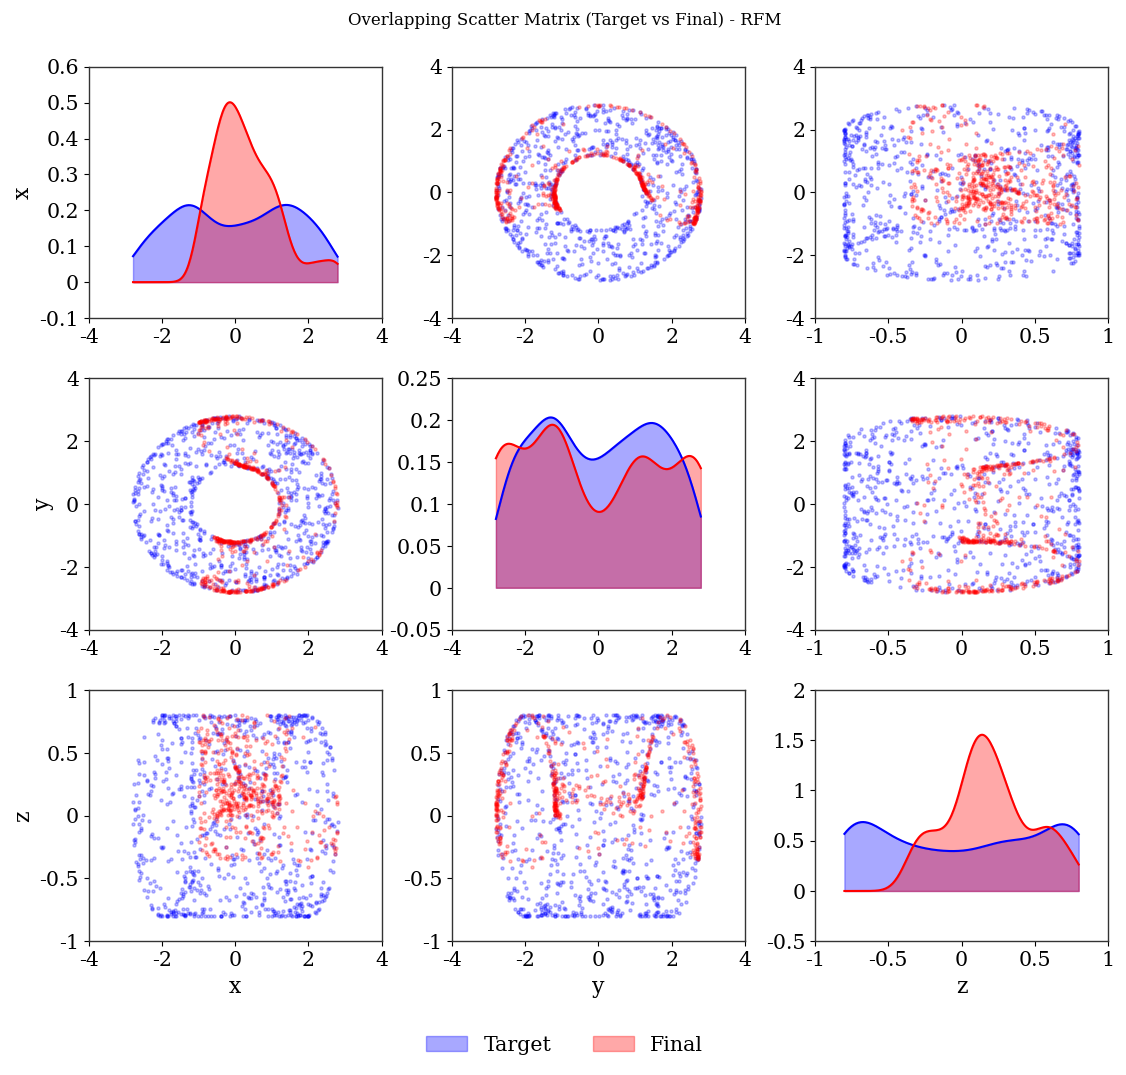

Caption: Overlapping scatter matrix comparing the torus target with final RFM particles.
Saved: figures/torus/baseline_rfm_overlap_matrix.png and figures/torus/baseline_rfm_overlap_matrix.pdf


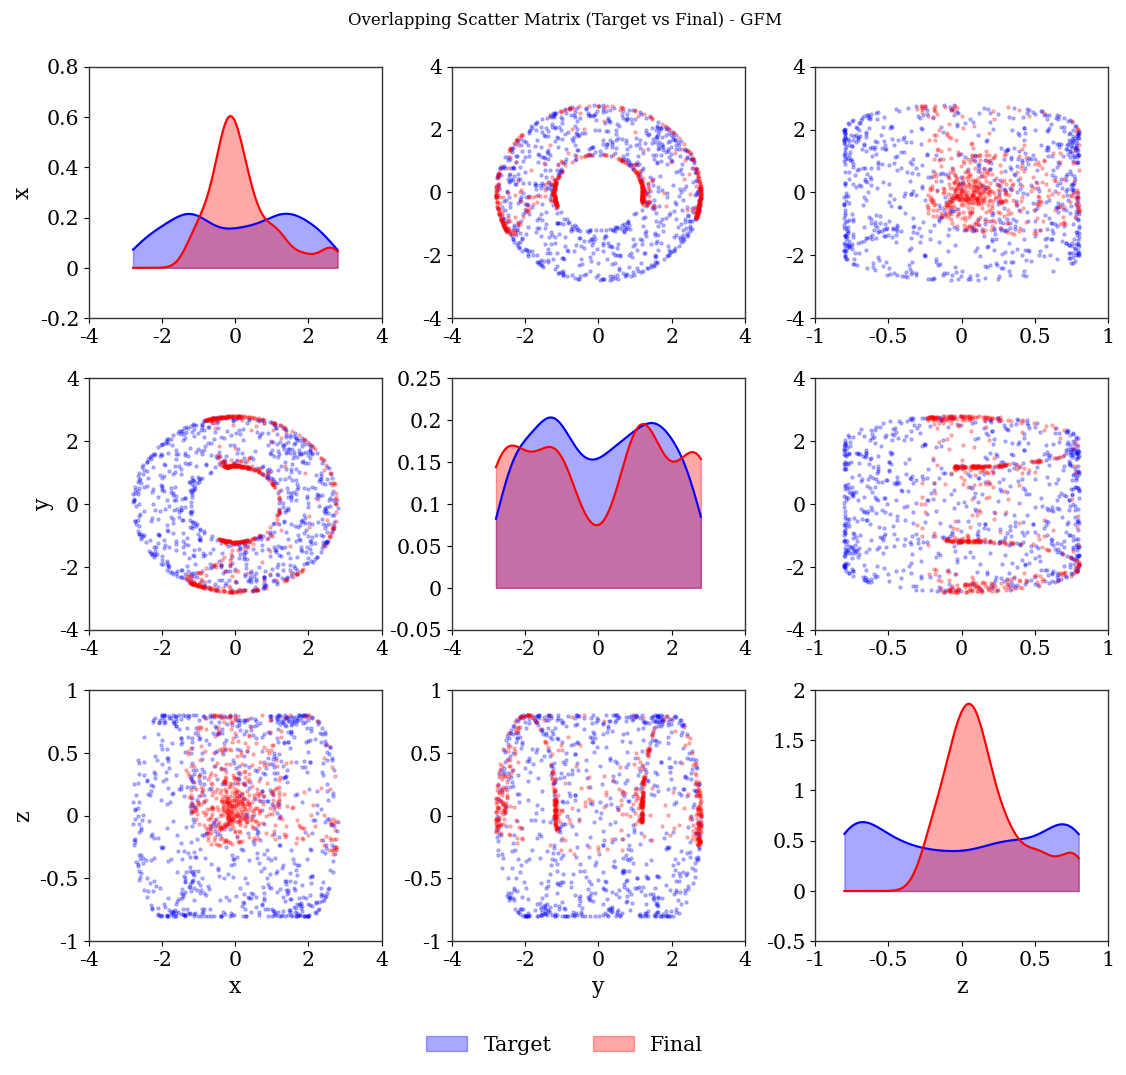

Caption: Overlapping scatter matrix comparing the torus target with final GFM particles.
Saved: figures/torus/baseline_gfm_overlap_matrix.png and figures/torus/baseline_gfm_overlap_matrix.pdf


In [4]:
for name in methods:
    plot_torus_overlap_matrix(
        X_tar, methods[name], method=name, mode='kde',
        stem=f'figures/torus/baseline_{name.lower().replace(" ", "_")}_overlap_matrix',
        caption=f'Overlapping scatter matrix comparing the torus target with final {name} particles.',
    )
